# Criando uma apresentação executiva

- vamos usar a base de vendas do kaggle disponivel em:
  - <https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting>

- O que queremos responder ?
    - Como foi a venda nesse periodo ?
    - Qual foi a categoria mais vendida ?
    - Qual foi o item mais vendido ?

### 1. Importando e visualizando a base
- Base: "Criando uma apresentação executiva.csv"

In [1]:
# Importando as bibliotecas e a Base

# Importa o numpy com o apelido np

import numpy as np

# Importa o pandas com o apelido pd
import pandas as pd

# Importa o pyplot com o apelido plt
import matplotlib.pyplot as plt

base = pd.read_csv('Criando uma apresentação executiva.csv')

base.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### 2. Entendendo e tratando a base

In [2]:
# Visualizando as informações da base

base.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [3]:
# Verificando os registros com postal code vazio

base[base['Postal Code'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [4]:
# Verificando se existe algum registro de Burlington, Vermont com Postal Code

base[(base['City'] == 'Burlington') & (base.State == 'Vermont')]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


## Buscar informação sobre o codigo postal diretamente no google

- usar o lock para buscar/localizar um valor

In [5]:
# Jeito errado de atualizar essa informação

base[(base['City'] == 'Burlington') & (base.State == 'Vermont') & (base['Postal Code'].isnull())]['Postal Code'] = 5401

## Caso quisesse dropar a coluna

base2 = base.drop('Postal Code', axis = 1)
base2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Region         9800 non-null   object 
 12  Product ID     9800 non-null   object 
 13  Category       9800 non-null   object 
 14  Sub-Category   9800 non-null   object 
 15  Product Name   9800 non-null   object 
 16  Sales          9800 non-null   float64
dtypes: float64(1), int64(1), object(15)
memory usage: 1.

/tmp/ipykernel_32867/208105678.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base[(base['City'] == 'Burlington') & (base.State == 'Vermont') & (base['Postal Code'].isnull())]['Postal Code'] = 5401


In [6]:
# Atualizando essa informação

base.loc[(base['City'] == 'Burlington') & (base.State == 'Vermont') & (base['Postal Code'].isnull()), "Postal Code"] = 5401

In [7]:
# Verificando se ainda existe algum valor nulo

base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9800 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [8]:
# Visualizando novamente as informações da base

base[(base['City'] == 'Burlington') & (base.State == 'Vermont') & (base['Postal Code'].isnull())]['Postal Code']


Series([], Name: Postal Code, dtype: float64)

# Como foi a venda nesse periodo ?

- aqui temos 2 questões que precisamos responder

- Como foi a venda nesse periodo ?
    - a venda a gente consegue verificar na coluna Sales
    - O período nós podemos usar a coluna "Order Date", mas precisamos entender melhor essa coluna



In [9]:
# Para entender a data, podemos ver de qual período estamos falando

base['Order Date'].min()



'01/01/2018'

### Cuidado: Se a coluna de data estiver como texto e não como data, a ordenação vai ser pelo texto e não pela data!

Podemos converter uma coluna para da usando o to_datetime do pandas

base["coluna"] = pd.to_datetime(base["coluna"])

- no datetime, caso tenha apenas a data, a hora ficaria como 00:00:00
- Se quisermos considerar apenas a data, podemos usado o .date da biblioteca datetime



In [10]:
import datetime as dt

# base['Order Date'] = pd.to_datetime(base['Order Date'])

base['Order Date'] = pd.to_datetime(base['Order Date'], format='%d/%m/%Y')
base['Ship Date'] = pd.to_datetime(base['Ship Date'], format='%d/%m/%Y')



In [11]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [12]:
## Buscando o min novamente porem no formato date
base['Order Date'].min()


Timestamp('2015-01-03 00:00:00')

In [13]:
base['Order Date'].max()


Timestamp('2018-12-30 00:00:00')

# Venda por ano

In [14]:
# Criando uma coluna com o ano
# Usando o groupby()
 
base['Ano'] = base['Order Date'].dt.year

base.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Ano
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016


In [15]:
# Usando essa coluna no group By e criando um plot de barras

base.groupby("Ano")["Sales"].sum()

Ano
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

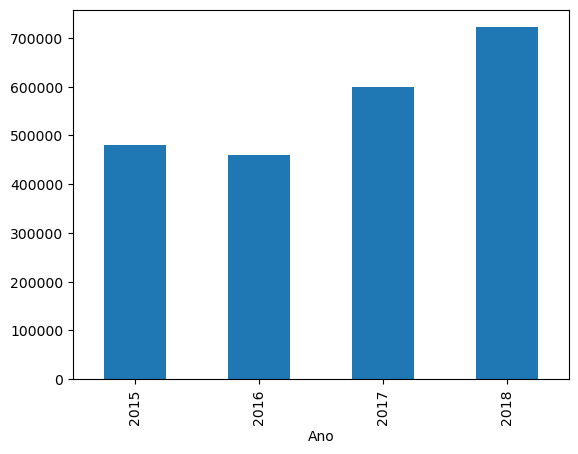

In [16]:
# Criando um plot para mostrar quanto vendeu em cada ano

base.groupby("Ano")["Sales"].sum().plot.bar();

## Melhorando o visual desse gráfico

- Como já vimos no ultimo tópico , podemos melhorar muito a visualização desse gráfico. Vamos fazer isso!
- Primeiramente vamos traçar um gráfico usando o que aprendemos de matplotlib
    - Segestão de cor: #84ba5b

In [17]:
import matplotlib.pyplot as plt
import numpy as np

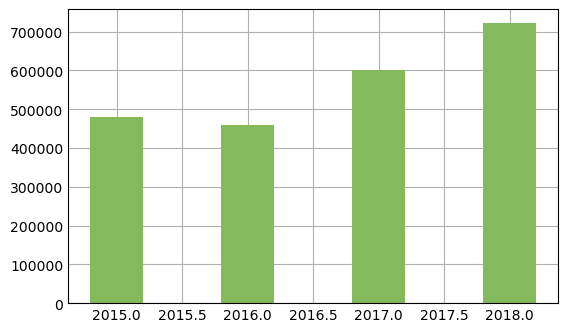

In [18]:
# Criando um gráfico com o matplotlib



plt.style.use('_mpl-gallery')

soma_ano = base.groupby("Ano")["Sales"].sum()
# plot
fig, ax = plt.subplots(figsize=(5,3))
# ax.plot(x.index, x.values, linewidth=2.0)
ax.bar(soma_ano.index, soma_ano.values, linewidth=2.0, color='#84ba5b', width=0.4)


plt.show()

### Adicionando o titulo e melhorando os textos do eixo

- Vamos adicionar o título e melhorar o eixo x
- o .set_title vai permitir colocar titulo e ajustar os parametros desse titulos
    - fontsize: tamanho da fonte
    - O xaxis.set_ticks vai definir os valores mostrados no eitxo X
    - O .tick_params(axis='x') vai ajustar o parâmetro do eixo x
        - labelsize: tamanho do label

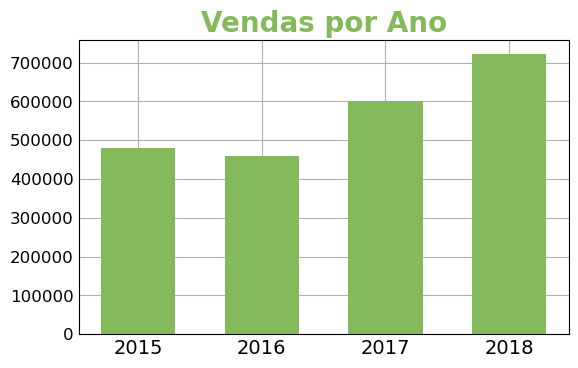

In [19]:
# Criando um gráfico com o matplotlib



plt.style.use('_mpl-gallery')

soma_ano = base.groupby("Ano")["Sales"].sum()
# plot
fig, ax = plt.subplots(figsize=(5,3))

ax.set_title ("Vendas por Ano", fontsize=20, fontweight='bold', color="#84ba5b")


# ax.plot(x.index, x.values, linewidth=2.0)
ax.bar(soma_ano.index, soma_ano.values, linewidth=2.0, color='#84ba5b', width=0.6)
ax.xaxis.set_ticks(soma_ano.index) # Remove o 2016.5
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y',labelsize=12)

plt.show()

### Colocando Rotulos nos Dados #F120

- Para adicionar rótulo de dados, vamos usar o .annotate como vimos na última aula

### Melhorando a visualização do gráfico

- Para o eixo y, podemos fazer igual fizemos para o eixo x
    - com .set_ytick vamos ajustar os valores do eixo y
    - O .yaxis.set_visible(False) permite reitrar os valores do eixo y, tornando nosso visual mais claro
- Já para retirar as bordas do gráfico, basta usar o .spines['top'].set_visible(False)





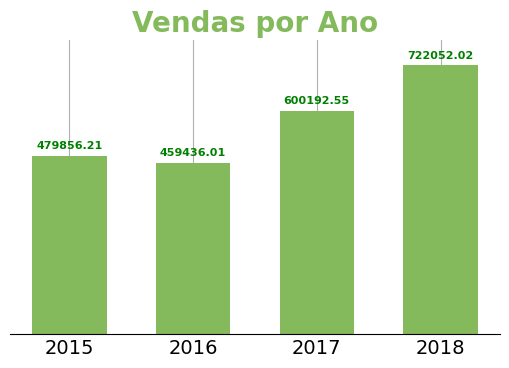

In [20]:
# Criando um gráfico com o matplotlib



plt.style.use('_mpl-gallery')

soma_ano = base.groupby("Ano")["Sales"].sum()
# plot
fig, ax = plt.subplots(figsize=(5,3))

ax.set_title ("Vendas por Ano", fontsize=20, fontweight='bold', color="#84ba5b")


# ax.plot(x.index, x.values, linewidth=2.0)
ax.bar(soma_ano.index, soma_ano.values, linewidth=2.0, color='#84ba5b', width=0.6)
ax.xaxis.set_ticks(soma_ano.index) # Remove o 2016.5
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y',labelsize=12)
for i in range(0,len(soma_ano)):
    ax.annotate('{:.2f}'.format(soma_ano.values[i]), # Texto
                (soma_ano.index[i], soma_ano.values[i]), # Posição X, Y
                ha="center",
                xytext=(0,5),
                textcoords="offset points",
                fontsize=8,
                color="green",
                fontweight="bold"
                )
    
# ax.set_yticks([0, soma_ano.values[-1] + 50000])
ax.set_yticks(np.array([0, 790000]))
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

# Venda por mês

- Também podemos mostra essa visão por meses
  - para isso, podemos usar o .month da biblioteca datetime para criar uma nova coluna apenas com o mês dessa base



In [21]:
# Criando uma coluna com o mês

base['Mes'] = base['Order Date'].dt.month

base.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Ano,Mes
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10


In [22]:
# Fazendo groupby agora por mês e ano

soma_mes = base.groupby(['Ano', 'Mes'])['Sales'].sum()


In [23]:
# Verificando os valores gerados

soma_mes.head()


Ano   Mes
2015  1      14205.707
      2       4519.892
      3      55205.797
      4      27906.855
      5      23644.303
Name: Sales, dtype: float64

In [24]:
soma_mes.index

# MultiIndex -> DataFrame
## Usando o .reset_index() Conseguimos transforma os indices 
## em colunas e então aplicar todas as propriedades que conhecemos para o DataFrame



MultiIndex([(2015,  1),
            (2015,  2),
            (2015,  3),
            (2015,  4),
            (2015,  5),
            (2015,  6),
            (2015,  7),
            (2015,  8),
            (2015,  9),
            (2015, 10),
            (2015, 11),
            (2015, 12),
            (2016,  1),
            (2016,  2),
            (2016,  3),
            (2016,  4),
            (2016,  5),
            (2016,  6),
            (2016,  7),
            (2016,  8),
            (2016,  9),
            (2016, 10),
            (2016, 11),
            (2016, 12),
            (2017,  1),
            (2017,  2),
            (2017,  3),
            (2017,  4),
            (2017,  5),
            (2017,  6),
            (2017,  7),
            (2017,  8),
            (2017,  9),
            (2017, 10),
            (2017, 11),
            (2017, 12),
            (2018,  1),
            (2018,  2),
            (2018,  3),
            (2018,  4),
            (2018,  5),
            (201

In [25]:
soma_mes = soma_mes.reset_index()

soma_mes

,Ano,Mes,Sales
0,2015,1,14205.7070
1,2015,2,4519.8920
2,2015,3,55205.7970
3,2015,4,27906.8550
4,2015,5,23644.3030
5,2015,6,34322.9356
6,2015,7,33781.5430
7,2015,8,27117.5365
8,2015,9,81623.5268
9,2015,10,31453.3930


In [26]:
soma_mes[soma_mes.Ano == 2015]

,Ano,Mes,Sales
0,2015,1,14205.7070
1,2015,2,4519.8920
2,2015,3,55205.7970
3,2015,4,27906.8550
4,2015,5,23644.3030
5,2015,6,34322.9356
6,2015,7,33781.5430
7,2015,8,27117.5365
8,2015,9,81623.5268
9,2015,10,31453.3930


## F122 - Entendendo o deslocamente das barras em um gráfico de barras horizontais


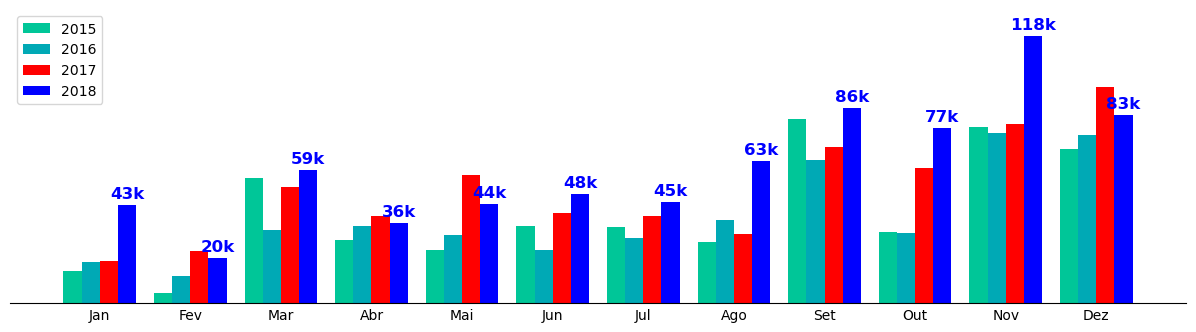

In [27]:
# Vamos uisa o gra´fico que fizemos na aula anterior para ir criando esse gráfico

# Criando um gráfico com o matplotlib



plt.style.use('_mpl-gallery')
soma_2015 = soma_mes[soma_mes.Ano == 2015]
soma_2016 = soma_mes[soma_mes.Ano == 2016]
soma_2017 = soma_mes[soma_mes.Ano == 2017]
soma_2018 = soma_mes[soma_mes.Ano == 2018]


soma_ano = base.groupby("Ano")["Sales"].sum()
# plot
fig, ax = plt.subplots(figsize=(12,3))

# ax.set_title ("Vendas por Ano", fontsize=20, fontweight='bold', color="#84ba5b")


# ax.plot(x.index, x.values, linewidth=2.0)
width = 0.2
ax.bar(soma_2015.Mes - width - width/2, soma_2015.Sales.values, linewidth=2.0, color='#00c698', width=width, label='2015')
ax.bar(soma_2016.Mes - width/2, soma_2016.Sales.values, linewidth=2.0, color='#00a9b5', width=width, label='2016')
ax.bar(soma_2017.Mes + width/2, soma_2017.Sales.values, linewidth=2.0, color='red', width=width, label='2017')
ax.bar(soma_2018.Mes + width + width/2, soma_2018.Sales.values, linewidth=2.0, color='blue', width=width, label='2018')
ax.legend()

# print(soma_mes)
for i in range(len(soma_2018.Mes)):
    ax.annotate(
                # '{:.0f}'.format(soma_2018.Sales.values[i]),
                '{:.0f}k'.format(soma_2018.Sales.values[i]/1000), 
                 
                (soma_2018.Mes.values[i]+width+width/2, soma_2018.Sales.values[i]),
                ha='center',
                color='blue',
                fontweight='bold',
                fontsize=12,
                xytext=(0,+5),
                textcoords="offset points",
                
                )

ax.set_yticks(np.array([0, 130000]))

ax.xaxis.set_ticks(np.arange(1,13))
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.show()

# Qual foi a categoria mais Vendida ?

- Precisamos primeiro entender a informação de categoria

In [28]:
# Podemos fazer um groupby da categoria

print(base.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

Como estamos dalando de 4 anos diferentes, seria interessante entender como foram essas categorias em cada um dos anos

In [29]:
# Agrupando por ano e categoria

base_category = base
soma_category = base_category.groupby(["Ano","Category"])["Sales"].sum()

# base_category['quantity'] = 1
# soma_category = base_category.groupby(["Ano","Category"])[["quantity","Sales"]].sum()
# soma_category = base.groupby("Category")["Sales"].sum()

soma_category


Ano   Category       
2015  Furniture          156477.8811
      Office Supplies    149512.8200
      Technology         173865.5070
2016  Furniture          164053.8674
      Office Supplies    133124.4070
      Technology         162257.7310
2017  Furniture          195813.0400
      Office Supplies    182417.5660
      Technology         221961.9440
2018  Furniture          212313.7872
      Office Supplies    240367.5410
      Technology         269370.6910
Name: Sales, dtype: float64

In [30]:
soma_category = soma_category.reset_index()
soma_category

,Ano,Category,Sales
0,2015,Furniture,156477.8811
1,2015,Office Supplies,149512.8200
2,2015,Technology,173865.5070
3,2016,Furniture,164053.8674
4,2016,Office Supplies,133124.4070
5,2016,Technology,162257.7310
6,2017,Furniture,195813.0400
7,2017,Office Supplies,182417.5660
8,2017,Technology,221961.9440
9,2018,Furniture,212313.7872


**Uma forma de visualizar melhor essas informações é fazer um gráfico de barras com esses dados, bem semelhante ao que fizemos acima**

     Ano         Category        Sales
0   2015        Furniture  156477.8811
1   2015  Office Supplies  149512.8200
2   2015       Technology  173865.5070
3   2016        Furniture  164053.8674
4   2016  Office Supplies  133124.4070
5   2016       Technology  162257.7310
6   2017        Furniture  195813.0400
7   2017  Office Supplies  182417.5660
8   2017       Technology  221961.9440
9   2018        Furniture  212313.7872
10  2018  Office Supplies  240367.5410
11  2018       Technology  269370.6910


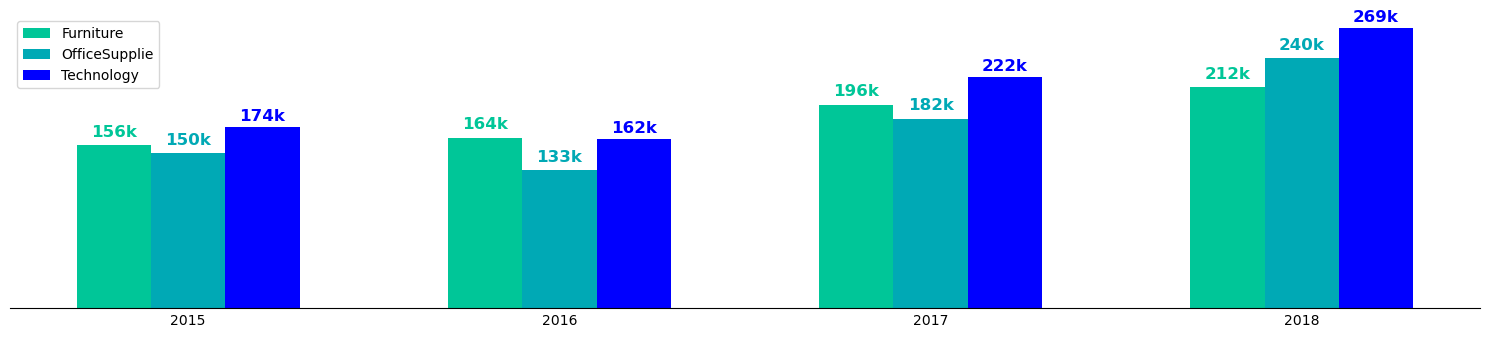

In [31]:
# Criando agora a Base de caregorias como fizemos anteriormente


print(soma_category)

plt.style.use('_mpl-gallery')


soma_cat_Furniture = soma_category[soma_category.Category == 'Furniture']
soma_cat_OfficeSupplie = soma_category[soma_category.Category == 'Office Supplies']
soma_cat_Technology = soma_category[soma_category.Category == 'Technology']


# plot
fig, ax = plt.subplots(figsize=(15,3))

# ax.set_title ("Vendas por Ano", fontsize=20, fontweight='bold', color="#84ba5b")


# ax.plot(x.index, x.values, linewidth=2.0)
width = 0.2
ax.bar(
       soma_cat_Furniture.Ano.values-width,
       soma_cat_Furniture.Sales.values,
       linewidth=2.0,
       color='#00c698',
       width=width,
       label='Furniture')


ax.bar(soma_cat_OfficeSupplie.Ano.values, soma_cat_OfficeSupplie.Sales.values, linewidth=2.0, color='#00a9b5', width=width, label='OfficeSupplie')
ax.bar(soma_cat_Technology.Ano.values+width, soma_cat_Technology.Sales.values, linewidth=2.0, color='blue', width=width, label='Technology')



for i in range(len(soma_cat_Technology.Ano)):
    ax.annotate(
                # '{:.0f}'.format(soma_2018.Sales.values[i]),
                '{:.0f}k'.format(soma_cat_Technology.Sales.values[i]/1000), 
                 
                (soma_cat_Technology.Ano.values[i]+width, soma_cat_Technology.Sales.values[i]),
                ha='center',
                color='blue',
                fontweight='bold',
                fontsize=12,
                xytext=(0,+5),
                textcoords="offset points",
                
                )
    
    
for i in range(len(soma_cat_OfficeSupplie.Ano)):
       ax.annotate(
                     # '{:.0f}'.format(soma_2018.Sales.values[i]),
                     '{:.0f}k'.format(soma_cat_OfficeSupplie.Sales.values[i]/1000), 
                     
                     (soma_cat_OfficeSupplie.Ano.values[i], soma_cat_OfficeSupplie.Sales.values[i]+2000),
                     ha='center',
                     color='#00a9b5',
                     fontweight='bold',
                     fontsize=12,
                     xytext=(0,+5),
                     textcoords="offset points",
              
              )

for i in range(len(soma_cat_Furniture.Ano)):
       ax.annotate(
                     # '{:.0f}'.format(soma_2018.Sales.values[i]),
                     '{:.0f}k'.format(soma_cat_Furniture.Sales.values[i]/1000), 
                     
                     (soma_cat_Furniture.Ano.values[i]-width, soma_cat_Furniture.Sales.values[i]+2000),
                     ha='center',
                     color='#00c698',
                     fontweight='bold',
                     fontsize=12,
                     xytext=(0,+5),
                     textcoords="offset points",
              
              )

ax.legend()


# ax.set_yticks(np.array([0, 130000]))

ax.xaxis.set_ticks(soma_cat_Furniture.Ano.values)
# ax.set_xticklabels(soma_cat_Furniture.Ano.values)

ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.show()

In [32]:
# Visualizando

Utilizando a mesma lógica do gráfico anterior

In [33]:
# Vamos utilizar o mesmo código do gráfico anterior para exibir por categorias

# Qual o item mais vendido ?

- vamos seguir exatamente a mesma lógica da categoria

**Podemos fazer a tabela considerando esses top itens**

- Para pegar uma base, podemos usar o .head() que ja conhecemos
- Podemos também usar o .sort_values()

In [34]:
# Podemos fazer um groupby do item

itens = base.groupby("Product Name")["Sales"].sum()

itens = itens.reset_index()
itens = itens.sort_values("Sales", ascending=False)
itens.head(10)

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


Um forma de resolver a quantidade de itens seria fazer apenas para os top 10 itens

In [35]:
# Os top n itens são

top_n_itens = itens.head(10)
top_n_itens

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


**Vamos traçar um gráfico de barras horizontais para mostrar os top 10 itens**

- <https://matplotlib.org/stable/gallery/lines_bars_and_markers/barh.html#sphx-glr-gallery-lines-bars-and-markers-barh-py>


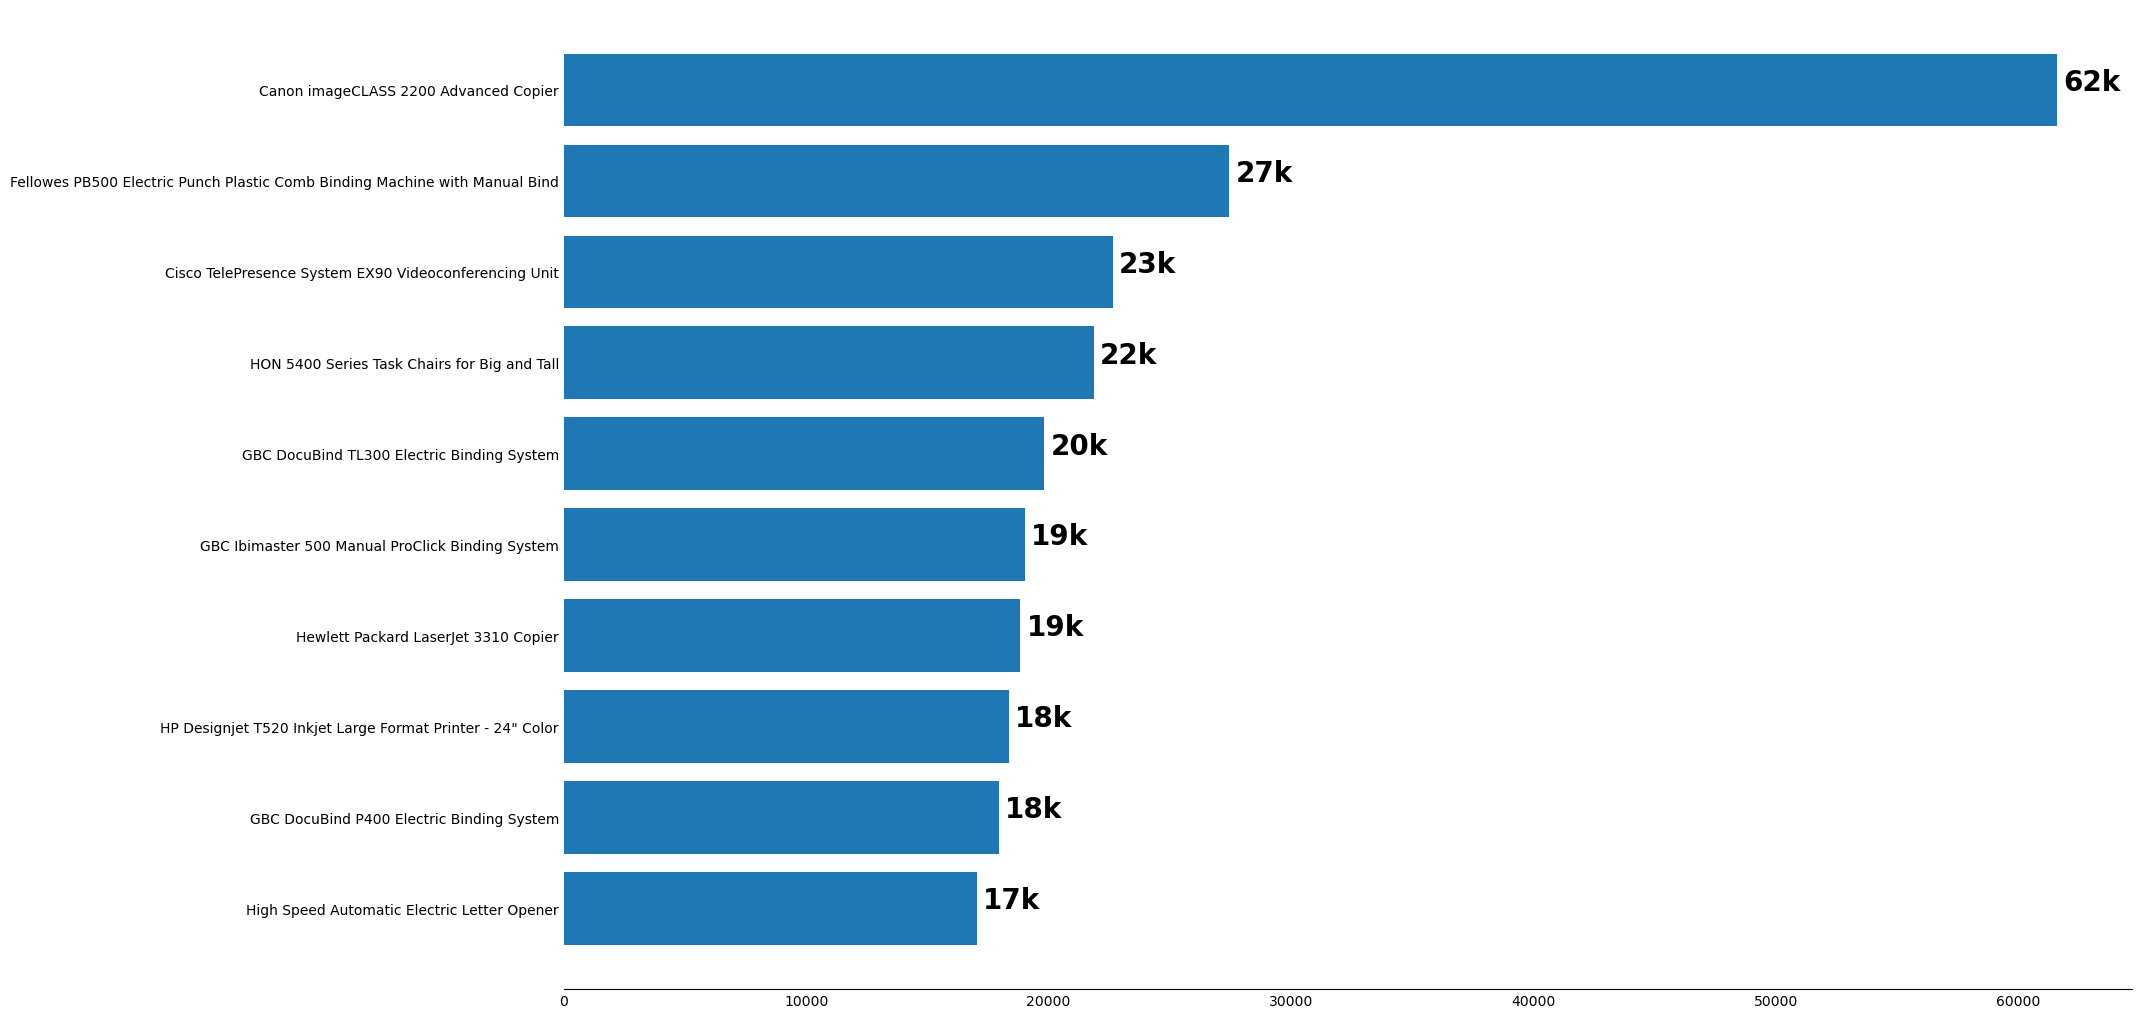

In [36]:
fig, ax = plt.subplots(
    figsize=(16,len(top_n_itens['Product Name'].values))
)

yValues = top_n_itens['Product Name'].values
xValues = top_n_itens['Sales'].values


ax.barh( 
        yValues,
        xValues,
        # xerr=error,
        align='center')

for i in range(len(top_n_itens['Product Name'].values)):
    ax.annotate(
                # '{:.0f}'.format(soma_2018.Sales.values[i]),
                '{:.0f}k'.format(top_n_itens['Sales'].values[i]/1000), 
                 
                (top_n_itens['Sales'].values[i], top_n_itens['Product Name'].values[i]),
                ha='center',
                color='black',
                fontweight='bold',
                fontsize=20,
                xytext=(25,0),
                textcoords="offset points",
                
                )


ax.invert_yaxis()
# ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.show()

In [37]:
# Podemos fazer um groupby de item e ano

itens_ano = base.groupby(["Product Name", "Ano"])["Sales"].sum()
itens_ano = itens_ano.reset_index()
itens_ano

,Product Name,Ano,Sales
0,"""While you Were Out"" Message Book, One Form pe...",2018,25.228
1,"#10 Gummed Flap White Envelopes, 100/Box",2016,6.608
2,"#10 Gummed Flap White Envelopes, 100/Box",2017,24.780
3,"#10 Gummed Flap White Envelopes, 100/Box",2018,9.912
4,#10 Self-Seal White Envelopes,2017,86.502
...,...,...,...
5269,invisibleSHIELD by ZAGG Smudge-Free Screen Pro...,2018,205.086
5270,netTALK DUO VoIP Telephone Service,2015,335.936
5271,netTALK DUO VoIP Telephone Service,2016,230.956
5272,netTALK DUO VoIP Telephone Service,2017,377.928


In [38]:
# Ver ano a ano pois algum produto pode ter vendido muito em um ano e ter parado de vender
itens_ano[itens_ano["Product Name"] == top_n_itens.iloc[1,0]]

,Product Name,Ano,Sales
1854,Fellowes PB500 Electric Punch Plastic Comb Bin...,2015,2033.584
1855,Fellowes PB500 Electric Punch Plastic Comb Bin...,2016,15760.276
1856,Fellowes PB500 Electric Punch Plastic Comb Bin...,2017,2287.782
1857,Fellowes PB500 Electric Punch Plastic Comb Bin...,2018,7371.742


## Juntando bases no pandas

O .merge() irá juntar duas bases

- Para isso, devemos passar:
    - base 1
    - base 2
    - how: forma quer iremos fazer essa junção das bases
        - inner: o que tiver em comum entre as 2 bases (base 1 e base 2)
        - outer: tudo o que tiver nas 2 bases (base 1 ou base 2)
        - left: tudo o que tem na primeira base, juntando com o que tiver na segunda
        - right: tudo que tiver na segunda base, juntando com o que tiver na primeira
    - on: coluna que vamos usar para fazer a junção





In [39]:
# Criando 2 dataframes

base_dic1 = {
             "nomes":['nome1', 'nome2', 'nome3'],
             "valores": [1,2,3]
             }

base_dic2 = {
             "nomes":['nome1', 'nome2', 'nome4'],
             "valores": [9,8,7]
             }

base_dic1 = pd.DataFrame(base_dic1)
base_dic2 = pd.DataFrame(base_dic2)

In [40]:
base_merge = pd.merge(
    base_dic1, # <- primera base 
    base_dic2, # <- segunda base
    how='right', # <- tipo de junção que vamos fazer
    on="nomes", # <- coluna que vamos usar para fazer essa junção das bases
)

display(base_merge)

,nomes,valores_x,valores_y
0,nome1,1.0,9
1,nome2,2.0,8
2,nome4,NaN,7


## Fazer o merge entre a base top_n_itens e uma base com as datas

Como podemos cruzar a base com todos os anos de 2015 a 2018

- Basta transformar as datas em um DataFrame e usar o merge para fazer a uniao

In [41]:


df_datas = pd.DataFrame([2018,2017,2016,2015])
display(df_datas)
df_datas.columns = ['Ano']
df_datas

,0
0,2018
1,2017
2,2016
3,2015


,Ano
0,2018
1,2017
2,2016
3,2015


Só que para conseguir unias as bases, precisamos ter uma coluna em comum entre elas

- Então podemos nas duas bases, criar uma coluna chamada uniao (ou qualquer outro nome) com o mesmo valor

In [42]:
# para evitar erros e so atribuir as colunas antes de pegar o head dela

df_datas['uniao'] = 'unir'
top_n_itens['uniao'] = 'unir'
display(df_datas)

/tmp/ipykernel_32867/4241591774.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_n_itens['uniao'] = 'unir'


,Ano,uniao
0,2018,unir
1,2017,unir
2,2016,unir
3,2015,unir


In [43]:
produto_ano = pd.merge(
    top_n_itens, # <- primera base 
    df_datas, # <- segunda base
    how='outer', # <- tipo de junção que vamos fazer
    on="uniao", # <- coluna que vamos usar para fazer essa junção das bases
)

display(produto_ano.head())
display(itens_ano.head())

produto_ano = pd.merge(
    produto_ano, # <- primera base 
    itens_ano, # <- segunda base
    how='left', # <- tipo de junção que vamos fazer
    on=["Product Name", "Ano"], # <- coluna que vamos usar para fazer essa junção das bases
)

display(produto_ano.head())


,Product Name,Sales,uniao,Ano
0,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2018
1,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2017
2,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2016
3,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2015
4,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,unir,2018


,Product Name,Ano,Sales
0,"""While you Were Out"" Message Book, One Form pe...",2018,25.228
1,"#10 Gummed Flap White Envelopes, 100/Box",2016,6.608
2,"#10 Gummed Flap White Envelopes, 100/Box",2017,24.780
3,"#10 Gummed Flap White Envelopes, 100/Box",2018,9.912
4,#10 Self-Seal White Envelopes,2017,86.502


,Product Name,Sales_x,uniao,Ano,Sales_y
0,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2018,35699.898
1,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2017,25899.926
2,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2016,NaN
3,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2015,NaN
4,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,unir,2018,7371.742


**Agora podemos usar esses dados para traçar o gráfico**

,Product Name,Sales_x,uniao,Ano,Sales_y
0,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2018,35699.898
1,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2017,25899.926
2,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2016,NaN
3,Canon imageCLASS 2200 Advanced Copier,61599.824,unir,2015,NaN
4,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,unir,2018,7371.742


['Canon imageCLASS 2200 Advanced Copier'
 'Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind'
 'Cisco TelePresence System EX90 Videoconferencing Unit'
 'HON 5400 Series Task Chairs for Big and Tall'
 'GBC DocuBind TL300 Electric Binding System'
 'GBC Ibimaster 500 Manual ProClick Binding System'
 'Hewlett Packard LaserJet 3310 Copier'
 'HP Designjet T520 Inkjet Large Format Printer - 24" Color'
 'GBC DocuBind P400 Electric Binding System'
 'High Speed Automatic Electric Letter Opener']


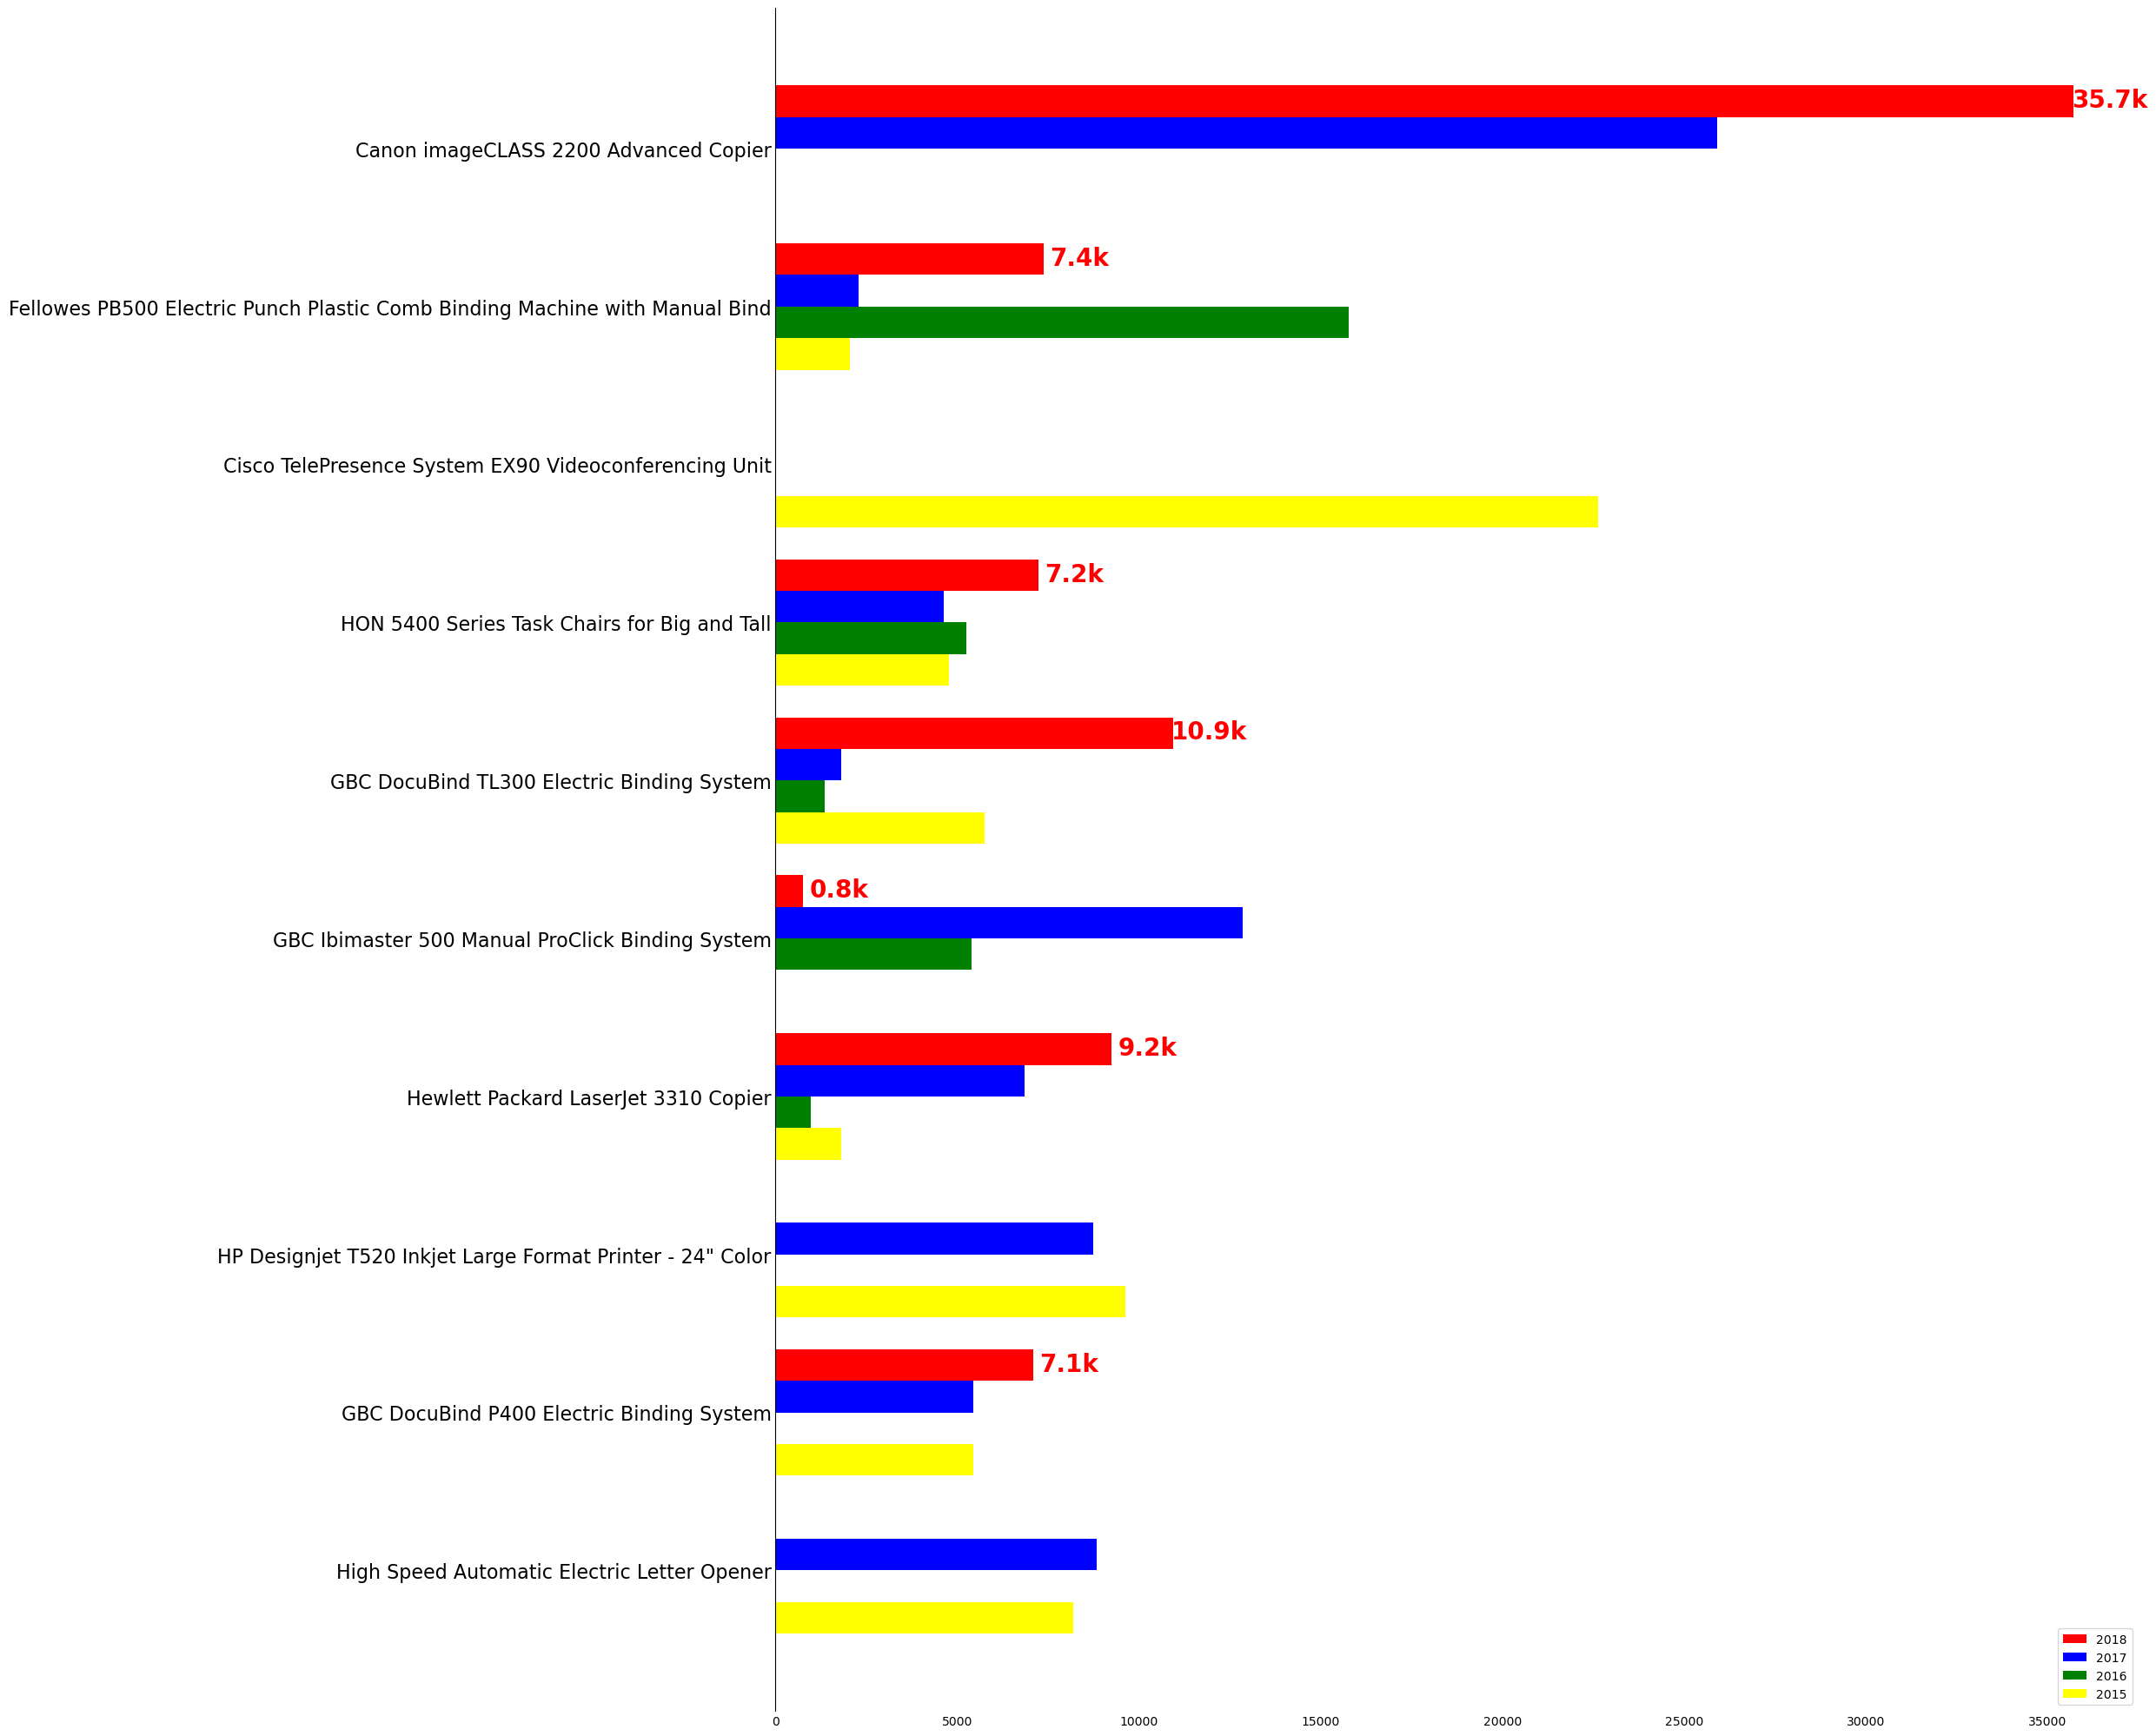

In [45]:
#F129 Vamos cria o gráfico nesse DataFrame que acabamos de criar
top = 5
display(produto_ano.head())

# produto_ano = {
#     "2018": produto_ano[produto_ano.Ano == 2018].head(top_n_itens),
#     "2017": produto_ano[produto_ano.Ano == 2017].head(top_n_itens),
#     "2016": produto_ano[produto_ano.Ano == 2016].head(top_n_itens)
# }

produto_name = produto_ano[produto_ano.Ano == 2018]["Product Name"].values
qtd_itens = len(produto_name)
produto_ano_2018 = produto_ano[produto_ano.Ano == 2018]
produto_ano_2017 = produto_ano[produto_ano.Ano == 2017]
produto_ano_2016 = produto_ano[produto_ano.Ano == 2016]
produto_ano_2015 = produto_ano[produto_ano.Ano == 2015]


print(produto_name)
fig, ax = plt.subplots(
        figsize=(16,qtd_itens*2)
)

hgt = 0.2

yValues = produto_name
color = '1'


ax.barh( 
        np.arange(0, qtd_itens)-hgt-hgt/2,
        produto_ano_2018.Sales_y.values,
        height=hgt,
        color='red',
        label='2018',
        align='center'
        )

ax.barh( 
        np.arange(0, qtd_itens)-hgt/2,
        produto_ano_2017.Sales_y.values,
        height=hgt,
        color='blue',
        label='2017',
        align='center')

ax.barh( 
        np.arange(0, qtd_itens)+hgt/2,
        produto_ano_2016.Sales_y.values,
        height=hgt,
        color='green',
        label='2016',
        align='center')

ax.barh( 
        np.arange(0, qtd_itens)+hgt+hgt/2,
        produto_ano_2015.Sales_y.values,
        height=hgt,
        color='yellow',
        label='2015',
        align='center')
for i in np.arange(0, qtd_itens):
    ax.annotate(
                # '{:.0f}'.format(soma_2018.Sales.values[i]),
                '{:.1f}k'.format(produto_ano_2018.Sales_y.values[i]/1000), 
                
                (produto_ano_2018.Sales_y.values[i], i-hgt-hgt/2),
                ha='center',
                color='red',
                fontweight='bold',
                fontsize=20,
                xytext=(30,-5),
                textcoords="offset points",
                )

ax.invert_yaxis()
# ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
# ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# ax.set_yticklabels(yValues)

ax.yaxis.set_ticks(np.arange(0,qtd_itens))
ax.set_yticklabels(produto_name)
ax.tick_params(axis='y', labelsize=16)

ax.grid(False)
ax.legend()
plt.show()

# Resumindo

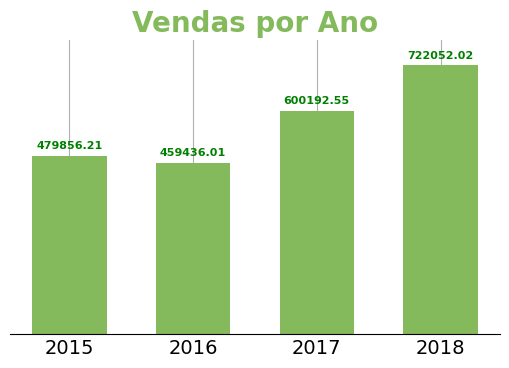

In [ ]:
# Criando um gráfico com o matplotlib



plt.style.use('_mpl-gallery')

soma_ano = base.groupby("Ano")["Sales"].sum()
# plot
fig, ax = plt.subplots(figsize=(5,3))

ax.set_title ("Vendas por Ano", fontsize=20, fontweight='bold', color="#84ba5b")


# ax.plot(x.index, x.values, linewidth=2.0)
ax.bar(soma_ano.index, soma_ano.values, linewidth=2.0, color='#84ba5b', width=0.6)
ax.xaxis.set_ticks(soma_ano.index) # Remove o 2016.5
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y',labelsize=12)
for i in range(0,len(soma_ano)):
    ax.annotate('{:.2f}'.format(soma_ano.values[i]), # Texto
                (soma_ano.index[i], soma_ano.values[i]), # Posição X, Y
                ha="center",
                xytext=(0,5),
                textcoords="offset points",
                fontsize=8,
                color="green",
                fontweight="bold"
                )
    
# ax.set_yticks([0, soma_ano.values[-1] + 50000])
ax.set_yticks(np.array([0, 790000]))
ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

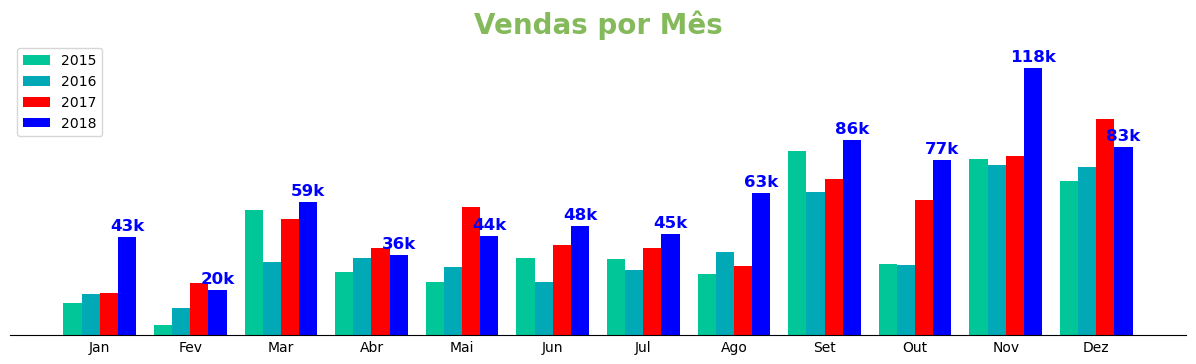

In [ ]:
# Vamos uisa o gra´fico que fizemos na aula anterior para ir criando esse gráfico

# Criando um gráfico com o matplotlib



plt.style.use('_mpl-gallery')
soma_2015 = soma_mes[soma_mes.Ano == 2015]
soma_2016 = soma_mes[soma_mes.Ano == 2016]
soma_2017 = soma_mes[soma_mes.Ano == 2017]
soma_2018 = soma_mes[soma_mes.Ano == 2018]


soma_ano = base.groupby("Ano")["Sales"].sum()
# plot
fig, ax = plt.subplots(figsize=(12,3))
ax.set_title ("Vendas por Mês", fontsize=20, fontweight='bold', color="#84ba5b")

# ax.set_title ("Vendas por Ano", fontsize=20, fontweight='bold', color="#84ba5b")


# ax.plot(x.index, x.values, linewidth=2.0)
width = 0.2
ax.bar(soma_2015.Mes - width - width/2, soma_2015.Sales.values, linewidth=2.0, color='#00c698', width=width, label='2015')
ax.bar(soma_2016.Mes - width/2, soma_2016.Sales.values, linewidth=2.0, color='#00a9b5', width=width, label='2016')
ax.bar(soma_2017.Mes + width/2, soma_2017.Sales.values, linewidth=2.0, color='red', width=width, label='2017')
ax.bar(soma_2018.Mes + width + width/2, soma_2018.Sales.values, linewidth=2.0, color='blue', width=width, label='2018')
ax.legend()

# print(soma_mes)
for i in range(len(soma_2018.Mes)):
    ax.annotate(
                # '{:.0f}'.format(soma_2018.Sales.values[i]),
                '{:.0f}k'.format(soma_2018.Sales.values[i]/1000), 
                 
                (soma_2018.Mes.values[i]+width+width/2, soma_2018.Sales.values[i]),
                ha='center',
                color='blue',
                fontweight='bold',
                fontsize=12,
                xytext=(0,+5),
                textcoords="offset points",
                
                )

ax.set_yticks(np.array([0, 130000]))

ax.xaxis.set_ticks(np.arange(1,13))
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.show()

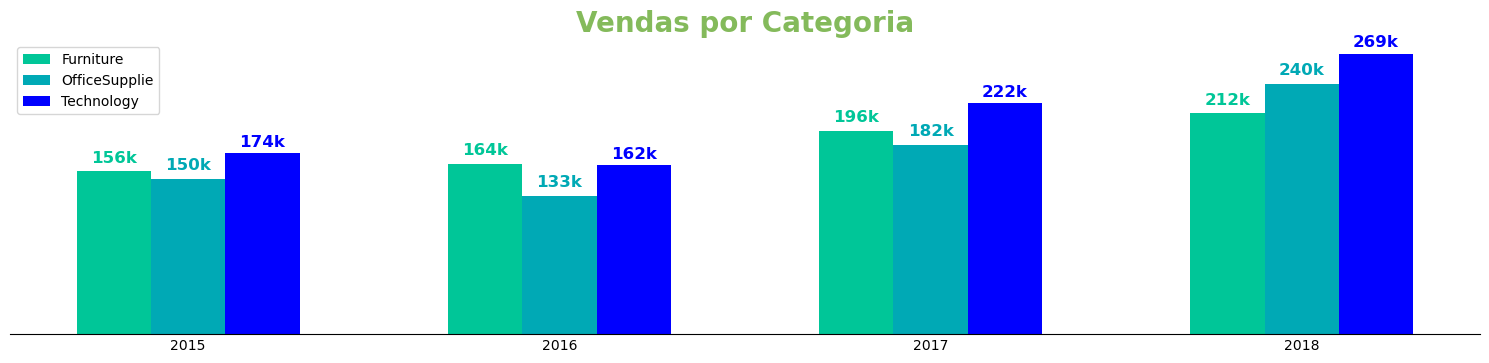

In [47]:
# Criando agora a Base de caregorias como fizemos anteriormente


plt.style.use('_mpl-gallery')


soma_cat_Furniture = soma_category[soma_category.Category == 'Furniture']
soma_cat_OfficeSupplie = soma_category[soma_category.Category == 'Office Supplies']
soma_cat_Technology = soma_category[soma_category.Category == 'Technology']


# plot
fig, ax = plt.subplots(figsize=(15,3))
ax.set_title ("Vendas por Categoria", fontsize=20, fontweight='bold', color="#84ba5b")

# ax.plot(x.index, x.values, linewidth=2.0)
width = 0.2
ax.bar(
       soma_cat_Furniture.Ano.values-width,
       soma_cat_Furniture.Sales.values,
       linewidth=2.0,
       color='#00c698',
       width=width,
       label='Furniture')


ax.bar(soma_cat_OfficeSupplie.Ano.values, soma_cat_OfficeSupplie.Sales.values, linewidth=2.0, color='#00a9b5', width=width, label='OfficeSupplie')
ax.bar(soma_cat_Technology.Ano.values+width, soma_cat_Technology.Sales.values, linewidth=2.0, color='blue', width=width, label='Technology')



for i in range(len(soma_cat_Technology.Ano)):
    ax.annotate(
                # '{:.0f}'.format(soma_2018.Sales.values[i]),
                '{:.0f}k'.format(soma_cat_Technology.Sales.values[i]/1000), 
                 
                (soma_cat_Technology.Ano.values[i]+width, soma_cat_Technology.Sales.values[i]),
                ha='center',
                color='blue',
                fontweight='bold',
                fontsize=12,
                xytext=(0,+5),
                textcoords="offset points",
                
                )
    
    
for i in range(len(soma_cat_OfficeSupplie.Ano)):
       ax.annotate(
                     # '{:.0f}'.format(soma_2018.Sales.values[i]),
                     '{:.0f}k'.format(soma_cat_OfficeSupplie.Sales.values[i]/1000), 
                     
                     (soma_cat_OfficeSupplie.Ano.values[i], soma_cat_OfficeSupplie.Sales.values[i]+2000),
                     ha='center',
                     color='#00a9b5',
                     fontweight='bold',
                     fontsize=12,
                     xytext=(0,+5),
                     textcoords="offset points",
              
              )

for i in range(len(soma_cat_Furniture.Ano)):
       ax.annotate(
                     # '{:.0f}'.format(soma_2018.Sales.values[i]),
                     '{:.0f}k'.format(soma_cat_Furniture.Sales.values[i]/1000), 
                     
                     (soma_cat_Furniture.Ano.values[i]-width, soma_cat_Furniture.Sales.values[i]+2000),
                     ha='center',
                     color='#00c698',
                     fontweight='bold',
                     fontsize=12,
                     xytext=(0,+5),
                     textcoords="offset points",
              
              )

ax.legend()


# ax.set_yticks(np.array([0, 130000]))

ax.xaxis.set_ticks(soma_cat_Furniture.Ano.values)
# ax.set_xticklabels(soma_cat_Furniture.Ano.values)

ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.show()

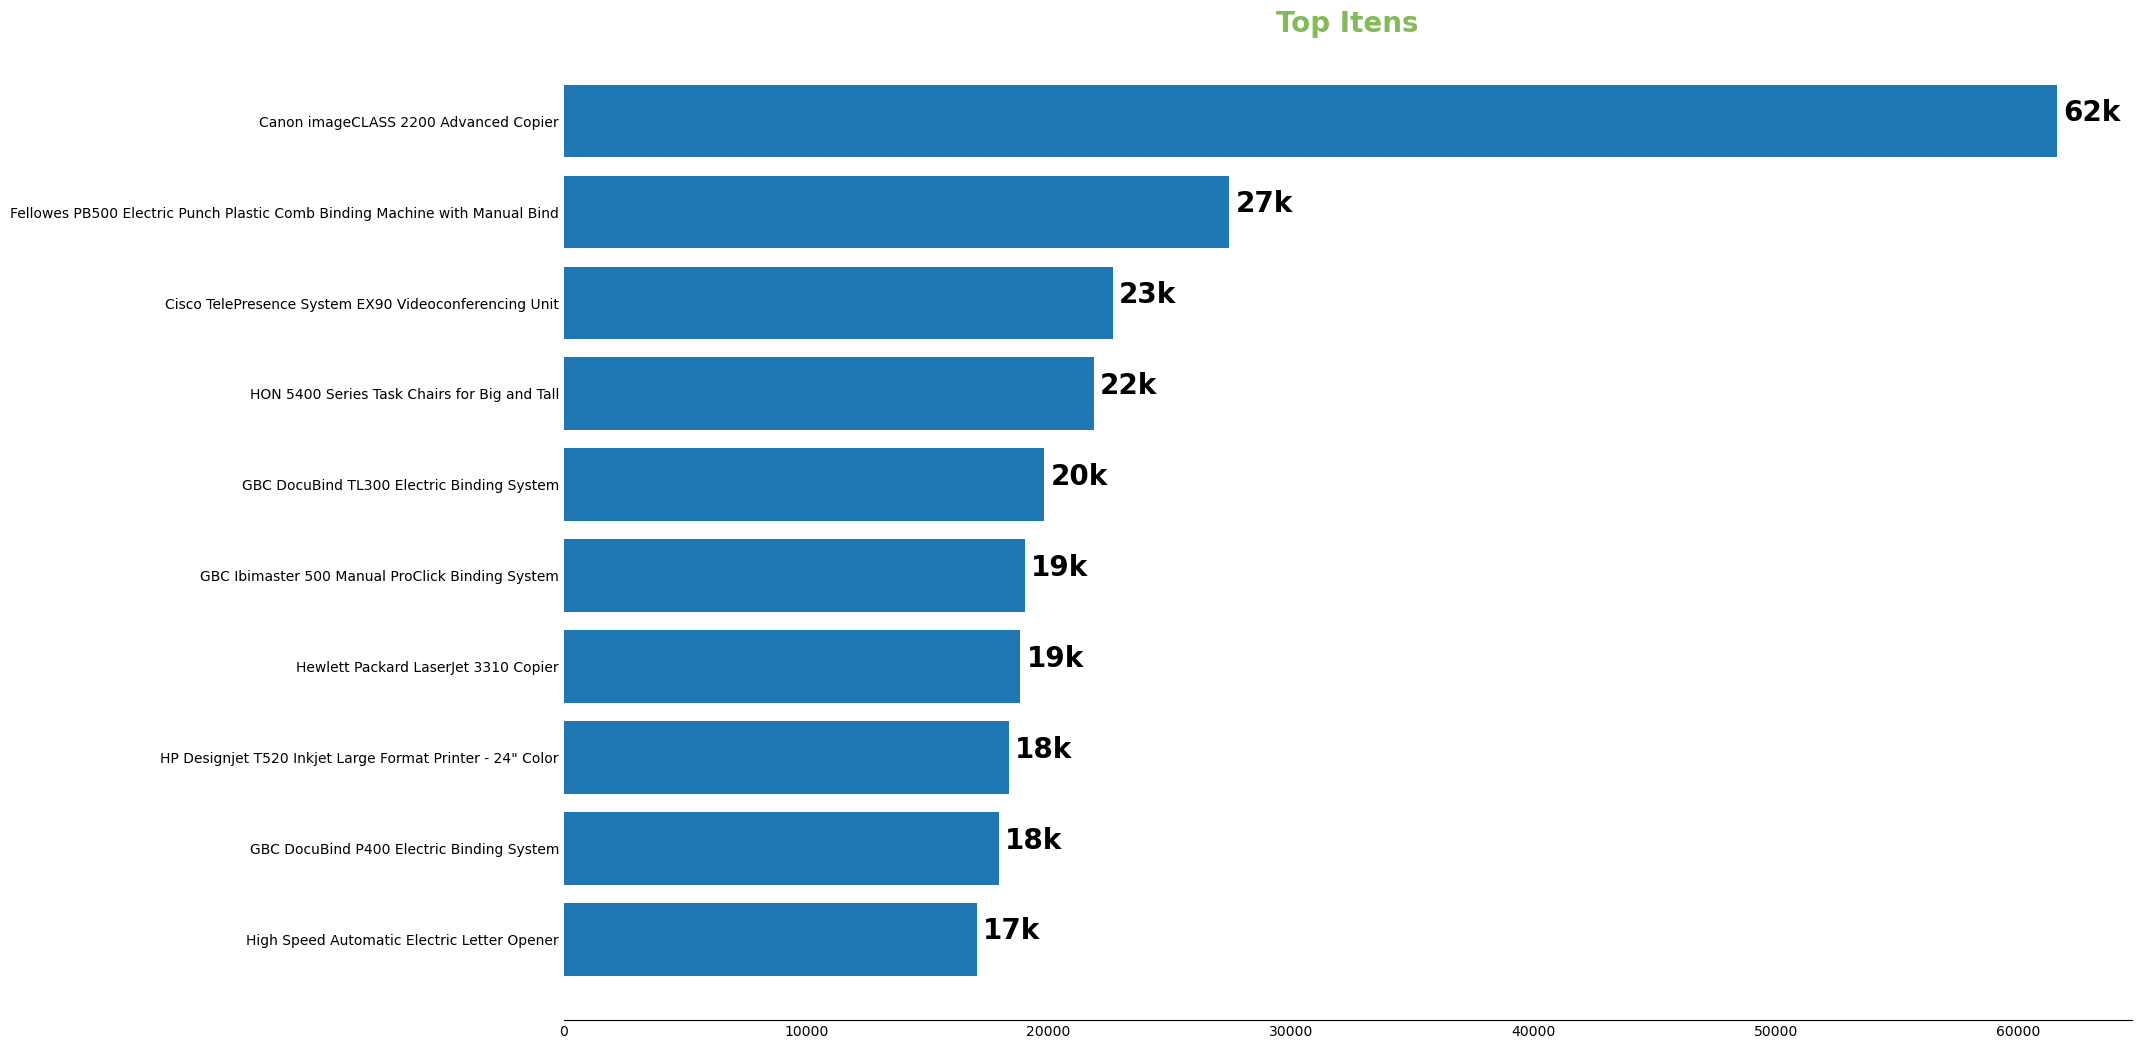

In [49]:
fig, ax = plt.subplots(
    figsize=(16,len(top_n_itens['Product Name'].values))
)
ax.set_title ("Top Itens", fontsize=20, fontweight='bold', color="#84ba5b")

yValues = top_n_itens['Product Name'].values
xValues = top_n_itens['Sales'].values


ax.barh( 
        yValues,
        xValues,
        # xerr=error,
        align='center')

for i in range(len(top_n_itens['Product Name'].values)):
    ax.annotate(
                # '{:.0f}'.format(soma_2018.Sales.values[i]),
                '{:.0f}k'.format(top_n_itens['Sales'].values[i]/1000), 
                 
                (top_n_itens['Sales'].values[i], top_n_itens['Product Name'].values[i]),
                ha='center',
                color='black',
                fontweight='bold',
                fontsize=20,
                xytext=(25,0),
                textcoords="offset points",
                
                )


ax.invert_yaxis()
# ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

plt.show()

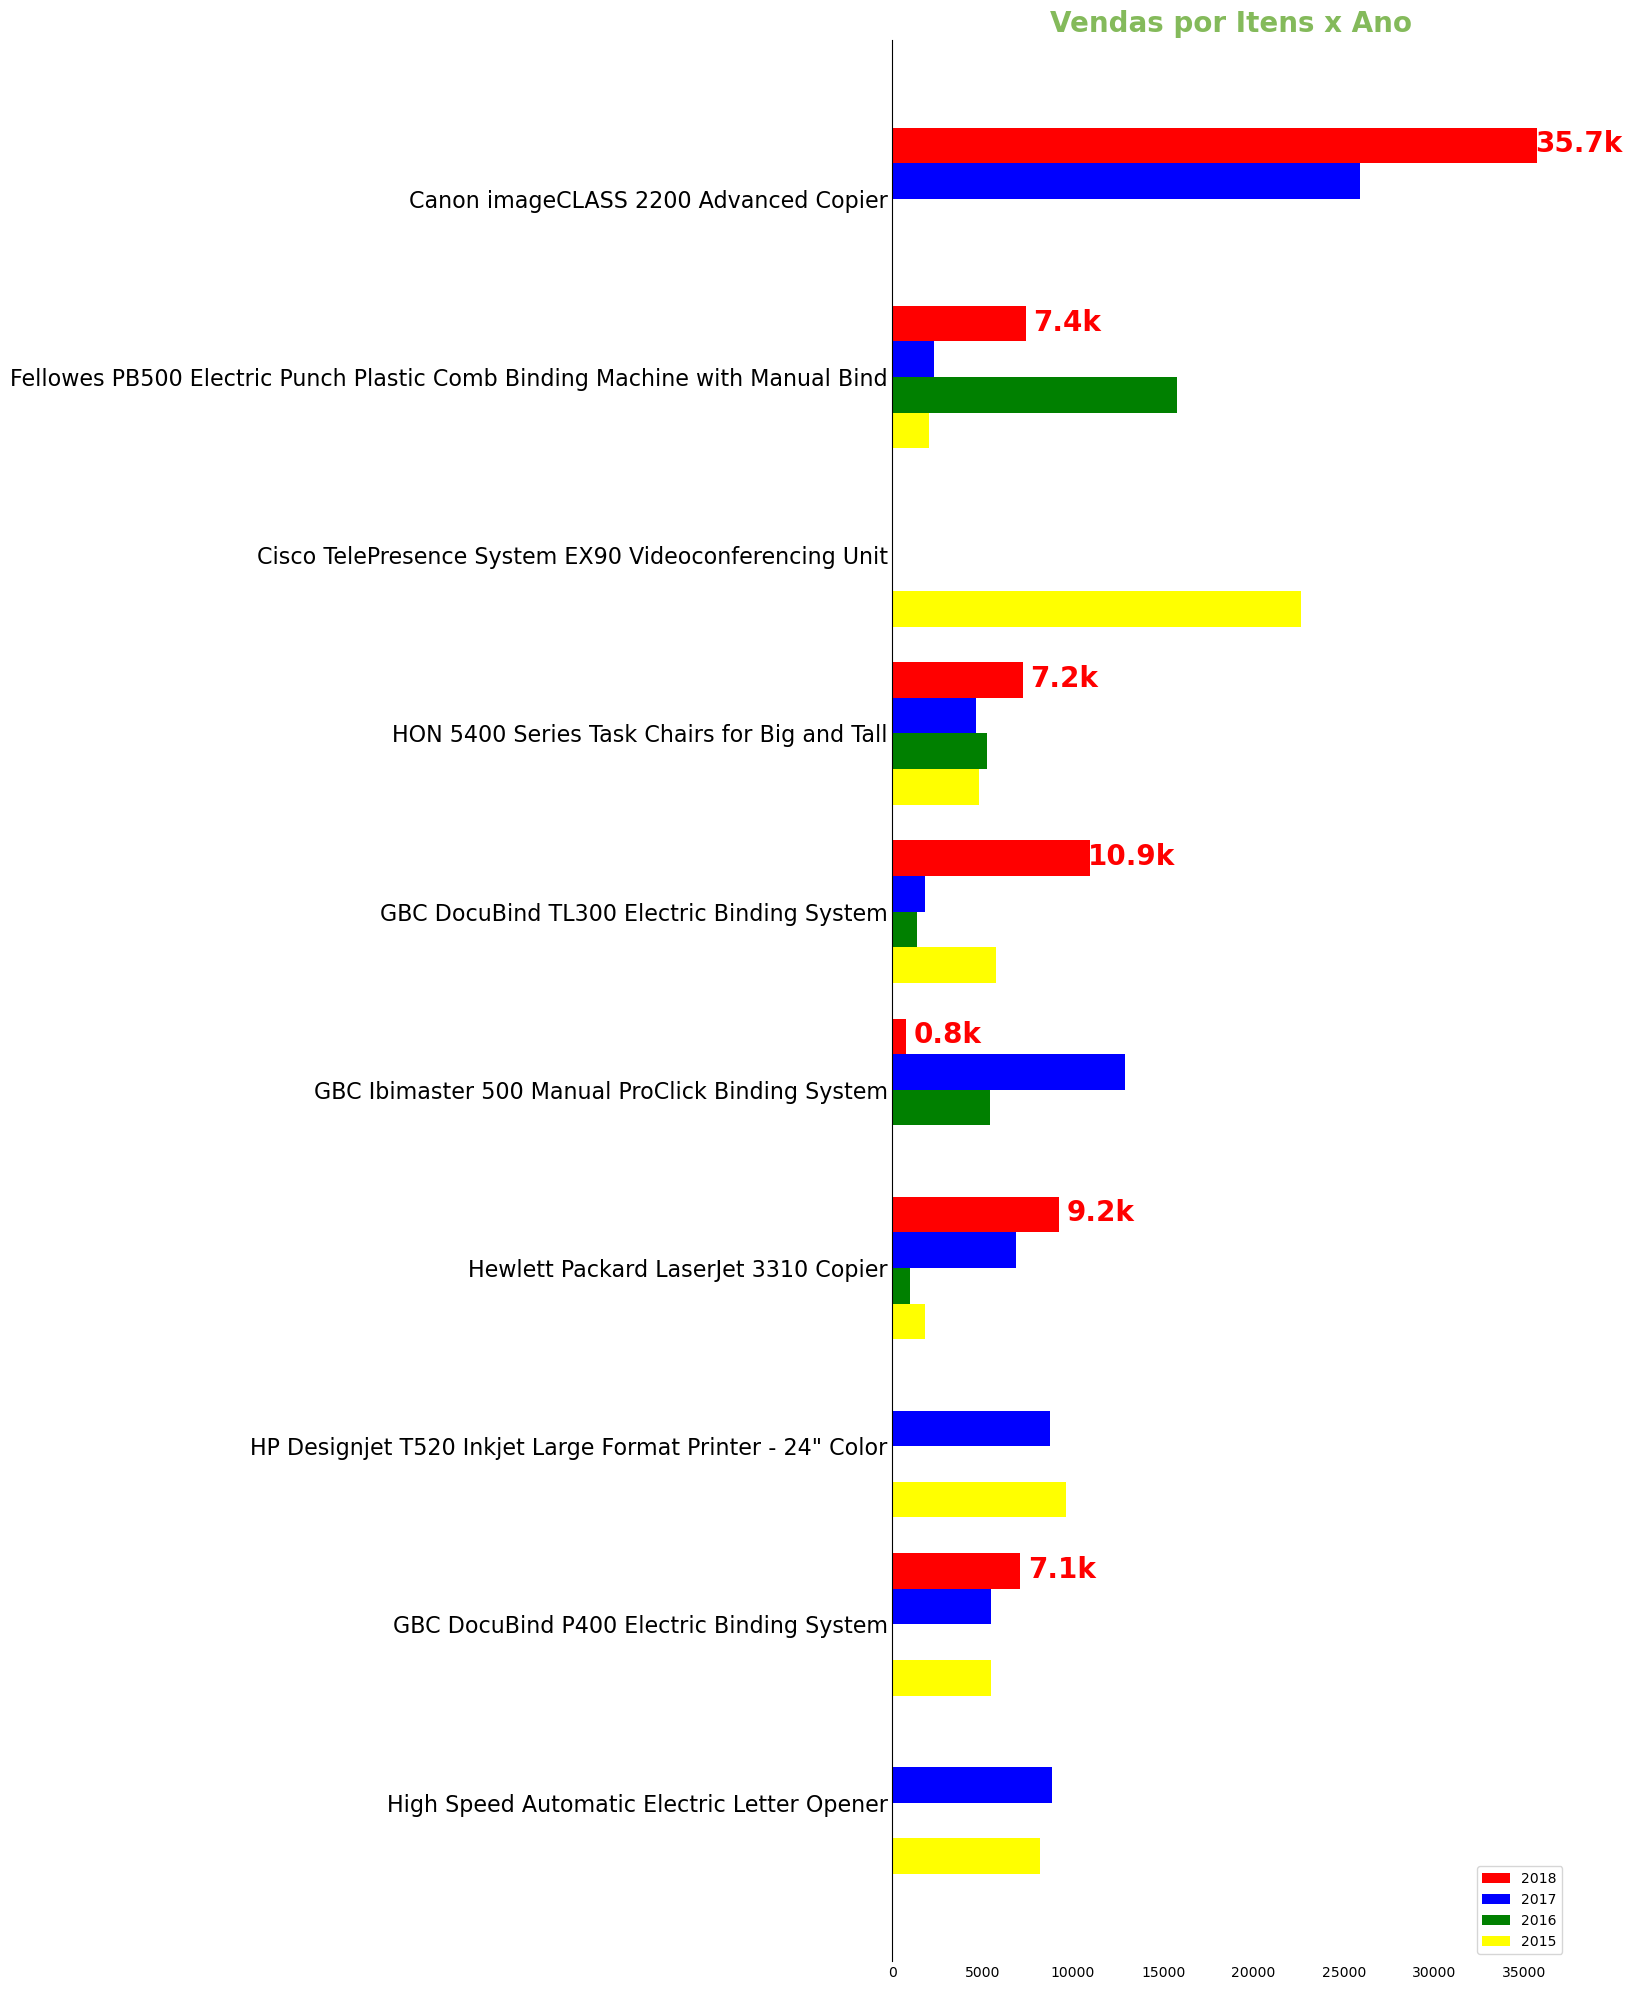

In [60]:
top = 5

produto_name = produto_ano[produto_ano.Ano == 2018]["Product Name"].values
qtd_itens = len(produto_name)
produto_ano_2018 = produto_ano[produto_ano.Ano == 2018]
produto_ano_2017 = produto_ano[produto_ano.Ano == 2017]
produto_ano_2016 = produto_ano[produto_ano.Ano == 2016]
produto_ano_2015 = produto_ano[produto_ano.Ano == 2015]


fig, ax = plt.subplots(
        figsize=(16,qtd_itens*2)
)
ax.set_title ("Vendas por Itens x Ano", fontsize=20, fontweight='bold', color="#84ba5b")

hgt = 0.2

yValues = produto_name
color = '1'


ax.barh( 
        np.arange(0, qtd_itens)-hgt-hgt/2,
        produto_ano_2018.Sales_y.values,
        height=hgt,
        color='red',
        label='2018',
        align='center'
        )

ax.barh( 
        np.arange(0, qtd_itens)-hgt/2,
        produto_ano_2017.Sales_y.values,
        height=hgt,
        color='blue',
        label='2017',
        align='center')

ax.barh( 
        np.arange(0, qtd_itens)+hgt/2,
        produto_ano_2016.Sales_y.values,
        height=hgt,
        color='green',
        label='2016',
        align='center')

ax.barh( 
        np.arange(0, qtd_itens)+hgt+hgt/2,
        produto_ano_2015.Sales_y.values,
        height=hgt,
        color='yellow',
        label='2015',
        align='center')
for i in np.arange(0, qtd_itens):
    ax.annotate(
                # '{:.0f}'.format(soma_2018.Sales.values[i]),
                '{:.1f}k'.format(produto_ano_2018.Sales_y.values[i]/1000), 
                
                (produto_ano_2018.Sales_y.values[i], i-hgt-hgt/2),
                ha='center',
                color='red',
                fontweight='bold',
                fontsize=20,
                xytext=(30,-5),
                textcoords="offset points",
                )

ax.invert_yaxis()
# ax.yaxis.set_visible(False)
ax.spines['top'].set_visible(False)
# ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# ax.set_yticklabels(yValues)

ax.yaxis.set_ticks(np.arange(0,qtd_itens))
ax.set_yticklabels(produto_name)
ax.tick_params(axis='y', labelsize=16)

ax.grid(False)
ax.legend()
plt.tight_layout()
plt.savefig('itensano', transparent=True)